In [ ]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

import xarray as xr
import pandas as pd
import geopandas as gpd
from glob import glob

import time

from cartopy.crs import Geodetic, PlateCarree
from cartopy.feature import LAND, COASTLINE

import warnings
warnings.simplefilter('ignore')

# Set Parameters

In [ ]:
# Parameters
year = 2024
site = 'LL17'
north_sea_locations = 'original'

isPapermill = False

In [3]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
map_size = (16, 8)
extent = (2.5, 27.5, 52, 62)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = PlateCarree()
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=['left', 'bottom'], y_inline=False,)
    return ax

In [5]:
# Paths
project_folder_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/')
trajectory_path = project_folder_path / f'output/Trajectories/{year}/'
sample_points_path = project_folder_path / f'output/SamplePoints/sample_points_{north_sea_locations}.geojson'
voronoi_polygons_path = project_folder_path / f'output/SamplePoints/voronoi_polygons_{north_sea_locations}.geojson'
output_path = project_folder_path / f'output/connectivity_{north_sea_locations}_locations/'

In [115]:
# Load the samplepoints and the voronoi polygons
sample_points = gpd.read_file(sample_points_path).set_index('location_id_old')
gdf_voronoi_polygons = gpd.read_file(voronoi_polygons_path)
# sample_ids = sample_points.location_id.to_list()
sample_ids = sample_points.index.to_list()
# Get site index, if the site name was given and the other way around
if type(site) == str:
    site_name = site
elif type(site) == int:
    # site_name = sample_points.iloc[site].name
    site_name = sample_ids[site]
# set starting site to 'active'
sample_points.loc[site_name]['sample_kind'] = 'active'

In [116]:
# Read and prepare the trajectory file
trajectory_file = sorted(trajectory_path.glob(f'*{site_name}*'))[0]
ds_trajectories = xr.open_zarr(trajectory_file)
# Make a mask that masks all days with an age under 10 days
trajectories_age_mask = ds_trajectories.age_sec.chunk(chunks=[2000,2784]).compute() > 10*24*60*60
# Only get the positions and mask
ds_trajectories = ds_trajectories.get(['lat','lon']).where(trajectories_age_mask, drop=True)

In [ ]:
# Take the positions and build a pandas dataframe out of it, making it as small as possible
df_trajectories = ds_trajectories.to_dataframe().dropna()
# removing the xr Datset, as it is not longer needed but big in the memory
del ds_trajectories

In [ ]:
# Build a Gepandas Gedataframe frm the dataframe and delete the df afterwards t safe n memry
gdf_trajectories = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df_trajectories['lon'], df_trajectories['lat'], crs=Geodetic()))
del df_trajectories

In [43]:
# Check for each particle which polygon contains it
gdf_trajectories = gdf_trajectories.sjoin(gdf_voronoi_polygons, how='left').drop(columns=['index_right', 'sample_kind'])

<Axes: xlabel='location_id'>

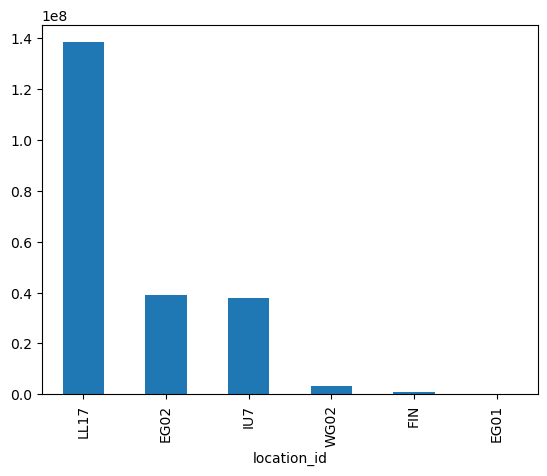

In [44]:
# Count the particles per polygon
polygon_count = gdf_trajectories.location_id.value_counts()
polygon_count.plot(kind='bar')

In [ ]:
# Write the counts per polygon into a connectivity matrix
output_file_path = output_path / f'connectivity_matrix_{north_sea_locations}_{year}.csv'
files_list = list(output_path.glob(f'connectivity_{north_sea_locations}_locations*'))

for n in range(10):
    # For the unlikely case, that multiple notebooks try to write in the same file, 
    # a mechanism to delay the writing process was employed
    try:
        # If the connectivity matrix for the given year already exists, thake that
        if output_file_path in files_list:
                connectivity_matrix = pd.read_csv(output_file_path, index_col=0)
                print('Updated file', output_file_path)
        else:
                connectivity_matrix = pd.DataFrame(index=sample_ids, columns=sample_ids).fillna(0)
                print('Created a new file', output_file_path)
        for polygon_id, count in polygon_count.items():
                connectivity_matrix.loc[[site_name], [polygon_id]] = count
        connectivity_matrix.to_csv(output_file_path)
        break
    except:
        print(np.random.rand()*n**2)
        time.sleep(np.random.rand()*n**2)
connectivity_matrix

Updated file /gxfs_work/geomar/smomw597/2025_copepods/output/VoronoiConnectivity/connectivitymatrix_voronoi_2024.csv


,KB03,SW08,BE01,GD01,IU07,LL17,FI01,SK02,WH02,KG01,...,SR03,WG01,WG02,BP03,BB23,BB36,GB96,HR21,IU7,FIN
SampleID,,,,,,,,,,,,,,,,,,,,,
KB03,148810913.0,22418499.0,44855843.0,0.0,0.0,0.0,0.0,0.0,0.0,2614508.0,...,0.0,0.0,0.0,0.0,30209.0,0.0,0.0,975141.0,NaN,NaN
SW08,18062079.0,167453939.0,2808145.0,0.0,0.0,0.0,0.0,0.0,0.0,5168527.0,...,0.0,0.0,0.0,0.0,275451.0,2348.0,0.0,25781663.0,NaN,NaN
BE01,50897202.0,16048977.0,150359134.0,0.0,0.0,0.0,0.0,0.0,0.0,2124608.0,...,0.0,0.0,0.0,0.0,1511.0,114.0,0.0,298751.0,NaN,NaN
GD01,0.0,0.0,0.0,219397242.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,506531.0,0.0,0.0,0.0,0.0,NaN,NaN
IU07,0.0,0.0,0.0,0.0,175982337.0,34577244.0,7540651.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
LL17,0.0,0.0,0.0,0.0,37312894.0,138475102.0,993367.0,0.0,0.0,0.0,...,0.0,0.0,3331139.0,0.0,0.0,0.0,0.0,0.0,38092456.0,1029419.0
FI01,0.0,0.0,0.0,0.0,979563.0,4591462.0,200496374.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
SK02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,203502831.0,273385.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
WH02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2604153.0,216494246.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


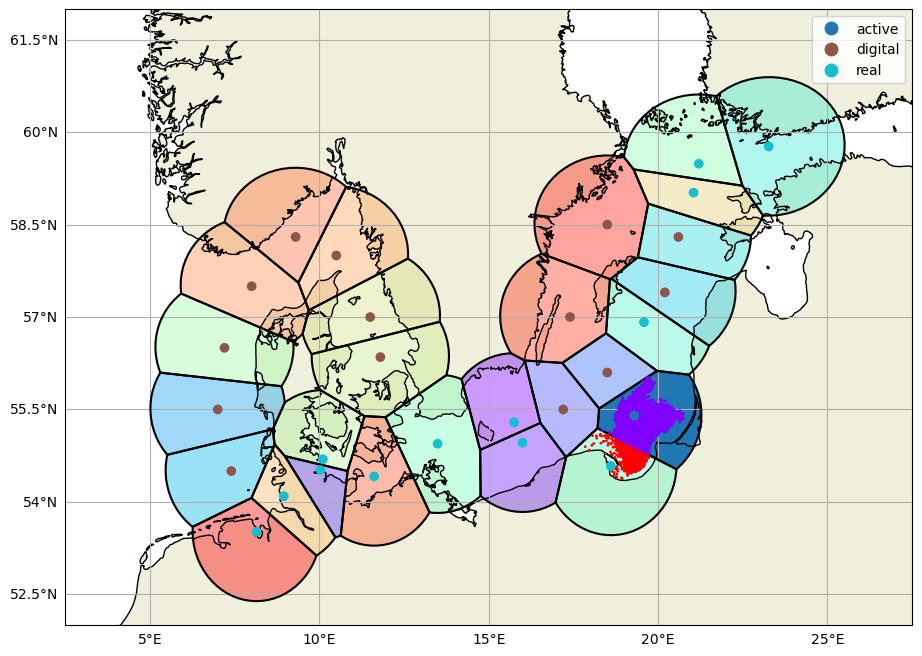

In [ ]:
fig = plt.figure(figsize=map_size)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.plot(ax=ax_map,alpha=0.4, column='location_id', cmap='rainbow')
gdf_voronoi_polygons.where(gdf_voronoi_polygons.location_id==site_name).plot(ax=ax_map, legend=True)
gdf_trajectories[::24*400].plot(ax=ax_map, column='location_id', cmap='rainbow', s=1, zorder=9)
gdf_voronoi_polygons.boundary.plot(ax=ax_map, color='k',)
sample_points.plot(ax=ax_map, column='sample_kind', legend=True, zorder=10)
plt.show()